In [1]:
import math
from contextlib import nullcontext
from typing import Optional

import torch
import torch.nn as nn
import torch.nn.functional as F


# GELU (Gaussian Error Linear Unit)

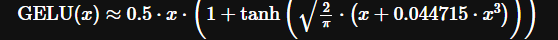



In [2]:
def _gelu(x : torch.Tensor) -> torch.Tensor:
    """Implementation of the gelu activation function.
    For information: OpenAI GPT's gelu is slightly different (and gives slightly different results)
    See:
    https://arxiv.org/abs/1606.08415
    """
    return 0.5* x * (1.0 + torch.tanh(math.sqrt(2.0 / math.pi) * (x + 0.044715 * torch.pow(x,3))))

# Expert FNN 

The clas ExpertFNN is implementation of a simple 2 layer MLP that serves as individual expert in MOE architecture /

* Input -> Linear -> GELU -> Dropout -> Linear -> Output 
 Param :

 * d_model : Input/output dim 
 * hidden : Hidden layer dimension
 * dropout : dropout rate for regularization

 

In [3]:
class ExpertFFN(nn.Module):
    def __init__(self,d_model,hidden,dropout=0.1):
        super(ExpertFFN,self).__init__()
        self.fc1 = nn.Linear(d_model,hidden,bias=False)
        self.fc2 = nn.Linear(hidden,d_model,bias=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self,x):
        return self.fc2(self.dropout(_gelu(self.fc1(x))))